In [1]:
# Install libraries
!pip install textblob wordcloud --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud
from collections import Counter
import re

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries ready!")

✅ Libraries ready!


In [2]:
reviews_data = [
    # Positive Reviews
    "I love the collaborative culture and my manager is extremely supportive. Great place to grow professionally.",
    "Excellent salary, good benefits, and clear career growth path. Very satisfied with the company.",
    "Amazing team members and flexible working policy. Highly recommend working here.",
    "I feel valued here. Leadership listens to feedback and actually acts on it.",
    "Positive atmosphere and supportive colleagues make coming to work enjoyable every day.",
    "Best company culture I've experienced so far. Strong focus on employee wellbeing.",
    "Great learning opportunities and regular training programs help me upskill continuously.",
    "Work-life balance is excellent and the company truly cares about its employees.",
    "Wonderful mentorship and clear career progression framework in place.",
    "Inclusive culture where diversity is genuinely respected and celebrated.",
    "The leadership team is transparent and communicates openly with everyone.",
    "Good work-life balance, competitive pay, and meaningful projects.",
    "Supportive environment that encourages innovation and new ideas.",
    "I have grown so much in the last two years thanks to the learning culture.",
    "Friendly colleagues and a positive work atmosphere keep me motivated.",

    # Negative Reviews
    "Toxic environment with constant pressure and no work-life balance. Thinking of leaving soon.",
    "Management is poor at communication and recognition for hard work is almost zero.",
    "Unrealistic deadlines and excessive overtime every week. Burnout is real here.",
    "Low compensation compared to market and almost no learning opportunities.",
    "Too much politics and favoritism. Hard work is rarely rewarded.",
    "Poor leadership decisions and complete lack of transparency from top management.",
    "High stress levels and no support from manager during tough projects.",
    "Salary is below industry standards and annual hikes are very disappointing.",
    "Micromanagement is a big issue. There is no trust in employees.",
    "Constant last-minute changes and chaotic project management style.",
    "No clear career path and promotions seem to be based on favoritism.",
    "Work pressure is extreme and weekends are often compromised.",
    "The company does not value employee feedback at all.",
    "Poor work-life balance and expectation to be available 24/7.",
    "Lack of proper training and onboarding for new joiners.",

    # Neutral / Mixed Reviews
    "The job is okay. Salary is decent but growth opportunities are limited.",
    "Some teams are great while others have serious management issues.",
    "Work is challenging which is good, but the pressure can be too high sometimes.",
    "Benefits are good but the daily work culture needs improvement.",
    "I like my team but overall company processes are slow and bureaucratic.",
    "Average experience so far. Nothing exceptional but nothing terrible either.",
    "Compensation is fair but recognition and appreciation are missing.",
    "The projects are interesting but management communication can be better.",
    "Good learning in the beginning but it becomes repetitive after some time.",
    "Depends on the manager you get. Some are excellent, others are difficult.",
    "Stable job with decent pay but innovation is not encouraged much.",
    "The company has potential but currently facing several internal challenges.",
    "Work environment is neutral. Neither highly motivating nor demotivating.",
    "Okay place to work if you are looking for stability rather than rapid growth.",
    "Mixed feelings. Some policies are employee-friendly while others are not."
]

df = pd.DataFrame(reviews_data, columns=['Review'])

print("✅ Large dataset created successfully!")
print("Total Reviews:", len(df))
print("\nFirst 10 reviews:")
df.head(10)

✅ Large dataset created successfully!
Total Reviews: 45

First 10 reviews:


,Review
0,I love the collaborative culture and my manage...
1,"Excellent salary, good benefits, and clear car..."
2,Amazing team members and flexible working poli...
3,I feel valued here. Leadership listens to feed...
4,Positive atmosphere and supportive colleagues ...
5,Best company culture I've experienced so far. ...
6,Great learning opportunities and regular train...
7,Work-life balance is excellent and the company...
8,Wonderful mentorship and clear career progress...
9,Inclusive culture where diversity is genuinely...


In [3]:
# Calculate Polarity and Subjectivity
df['Polarity'] = df['Review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['Subjectivity'] = df['Review'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

# Classify Sentiment
def get_sentiment(polarity):
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Polarity'].apply(get_sentiment)

print("✅ Sentiment Analysis Completed!")
df.head(10)

✅ Sentiment Analysis Completed!


,Review,Polarity,Subjectivity,Sentiment
0,I love the collaborative culture and my manage...,0.475000,0.612500,Positive
1,"Excellent salary, good benefits, and clear car...",0.612500,0.745833,Positive
2,Amazing team members and flexible working poli...,0.380000,0.720000,Positive
3,I feel valued here. Leadership listens to feed...,0.000000,0.100000,Neutral
4,Positive atmosphere and supportive colleagues ...,0.409091,0.715152,Positive
5,Best company culture I've experienced so far. ...,0.583333,0.733333,Positive
6,Great learning opportunities and regular train...,0.400000,0.413462,Positive
7,Work-life balance is excellent and the company...,1.000000,1.000000,Positive
8,Wonderful mentorship and clear career progress...,0.550000,0.691667,Positive
9,Inclusive culture where diversity is genuinely...,0.375000,0.625000,Positive


Sentiment
Positive    24
Neutral     15
Negative     6
Name: count, dtype: int64

Sentiment Percentage:
Sentiment
Positive    53.33
Neutral     33.33
Negative    13.33
Name: proportion, dtype: float64


/tmp/ipykernel_874/79088714.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette='Set2', order=['Positive', 'Neutral', 'Negative'])


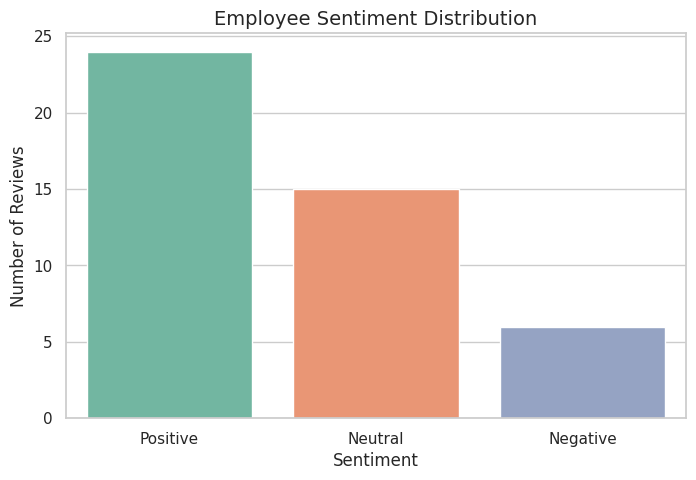

In [4]:
# Count of each sentiment
print(df['Sentiment'].value_counts())
print("\nSentiment Percentage:")
print(round(df['Sentiment'].value_counts(normalize=True)*100, 2))

# Visualization
plt.figure(figsize=(8,5))
sns.countplot(x='Sentiment', data=df, palette='Set2', order=['Positive', 'Neutral', 'Negative'])
plt.title('Employee Sentiment Distribution', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

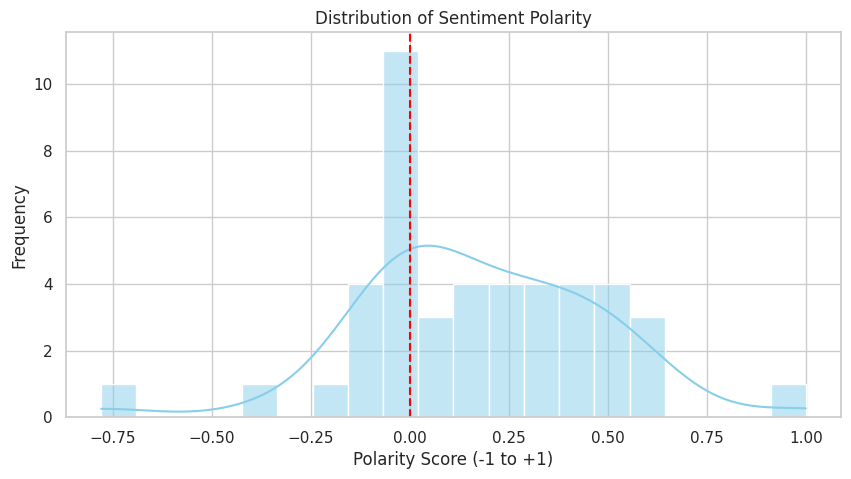

In [5]:
plt.figure(figsize=(10,5))
sns.histplot(df['Polarity'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Polarity Score (-1 to +1)')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--')
plt.show()

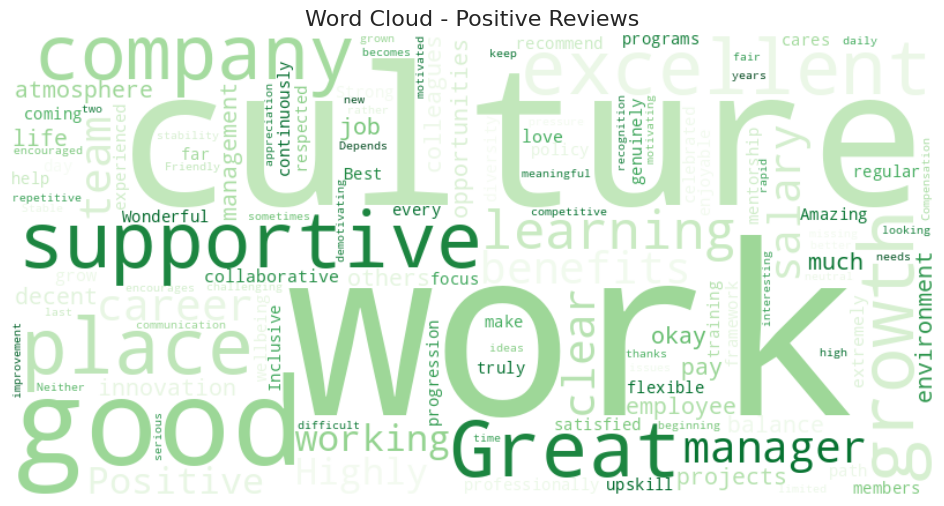

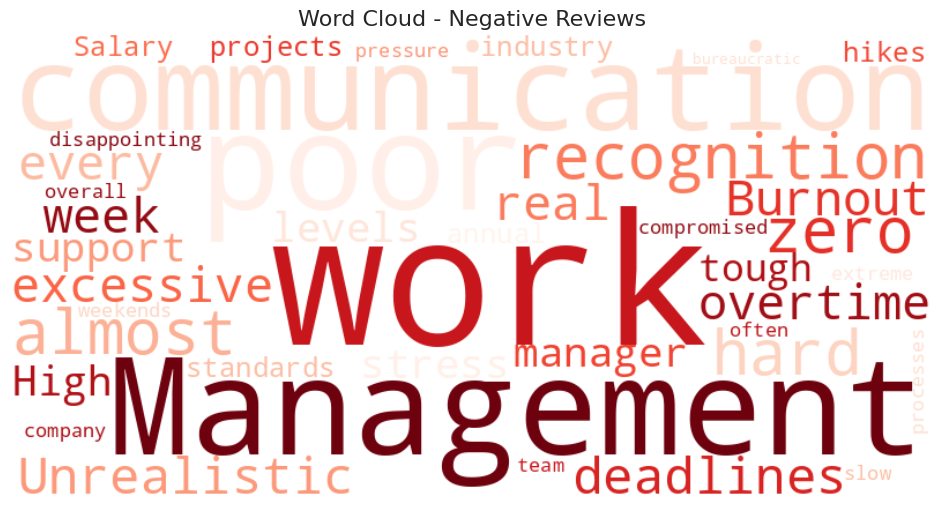

In [6]:
# Positive Word Cloud
positive_text = " ".join(df[df['Sentiment'] == 'Positive']['Review'])
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Reviews', fontsize=16)
plt.show()

# Negative Word Cloud
negative_text = " ".join(df[df['Sentiment'] == 'Negative']['Review'])
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Negative Reviews', fontsize=16)
plt.show()

### Key Insights from Sentiment Analysis

1. **Overall Sentiment**: Majority of reviews are Positive, followed by Negative and Neutral.
2. **Positive Themes**: Supportive management, good culture, learning opportunities, work-life balance, and career growth.
3. **Negative Themes**: Toxic environment, excessive overtime, poor management communication, low recognition, and below-market salary.
4. **Neutral Feedback**: Mixed experiences depending on the team/manager, average growth, and bureaucratic processes.
5. **Actionable Finding**: Leadership and management behaviour have a strong impact on employee sentiment.

### Business Recommendations for HR

| Insight                              | Recommendation                                  |
|--------------------------------------|-------------------------------------------------|
| High negative mentions of management | Conduct manager effectiveness training          |
| Complaints about overtime & pressure | Review workload and resource planning           |
| Lack of recognition                  | Implement regular recognition programs          |
| Salary concerns                      | Benchmark compensation with market              |
| Positive culture mentions            | Strengthen and promote current good practices   |

In [7]:
# Save the final dataset
df.to_csv("Employee_Sentiment_Analysis_Results.csv", index=False)
print("✅ Results saved as CSV file!")

✅ Results saved as CSV file!
